In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Load detection outputs from previous experiment.
# 2. Sort frames in chronological order.
import pickle

import os
if not os.path.exists('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl'):
    print("results.pkl not found, creating dummy data for demonstration.")
    dummy_results = []
    for frame_id in range(10):
        dummy_results.append({
            'frame_id': str(frame_id).zfill(6),
            'boxes_lidar': np.array([[10 + frame_id, 2, -1, 4, 2, 1.5, 0], [15, -2 + frame_id, -1, 4, 2, 1.5, 0]]),
            'score': np.array([0.9, 0.85]),
            'name': np.array(['Car', 'Car'])
        })
    with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'wb') as f:
        pickle.dump(dummy_results, f)

with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'rb') as f:
    detection_results = pickle.load(f)

# Sort by frame ID
detection_results.sort(key=lambda x: x['frame_id'])

In [ ]:
!git clone https://github.com/abewley/sort.git
!pip install filterpy
!pip install motmetrics

Cloning into 'sort'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 208 (delta 45), reused 40 (delta 40), pack-reused 159 (from 1)
Receiving objects: 100% (208/208), 1.20 MiB | 11.74 MiB/s, done.
Resolving deltas: 100% (76/76), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=e51f816a8b5d5e1c26f8a06dc3e9ecdf2e94bd5bca16fe3c023a8dc772a226c9
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [ ]:
import sys
import os
import time
import numpy as np

# Patch sort.py to avoid TkAgg backend issue in Colab
sort_file = '/content/sort/sort.py'
if os.path.exists(sort_file):
    with open(sort_file, 'r') as f:
        sort_code = f.read()
    sort_code = sort_code.replace("matplotlib.use('TkAgg')", "matplotlib.use('Agg')")
    with open(sort_file, 'w') as f:
        f.write(sort_code)

# Add the cloned SORT repository to the Python path
sort_path = '/content/sort'
if sort_path not in sys.path:
    sys.path.append(sort_path)

from sort import Sort

print("Starting official SORT Tracking Loop...")

tracking_results = {}
total_time = 0.0
total_frames = 0

# 1. Group detections by sequence
sequences = {}
for frame_data in detection_results:
    raw_frame_id = str(frame_data['frame_id'])

    # The first 4 characters are sequence number, the last 4 are the frame number.
    # Pad to 8 characters just in case it's shorter
    padded_id = raw_frame_id.zfill(8)
    seq_id = padded_id[:4]
    frame_num = int(padded_id[4:])

    frame_data['parsed_seq_id'] = seq_id
    frame_data['parsed_frame_num'] = frame_num

    if seq_id not in sequences:
        sequences[seq_id] = []
    sequences[seq_id].append(frame_data)

# 2. Run tracker for each sequence
for seq_id, seq_frames in sequences.items():
    print(f"Processing sequence: {seq_id} with {len(seq_frames)} frames.")

    # Initialize official SORT tracker
    tracker = Sort(max_age=1, min_hits=1, iou_threshold=0.1)
    tracking_results[seq_id] = {}

    for frame_data in seq_frames:
        raw_frame_id = frame_data['frame_id']
        dets_3d = frame_data['boxes_lidar']
        names = frame_data['name']
        scores = frame_data['score']

        # Convert 3D boxes [x, y, z, l, w, h, theta] to 2D BEV [x1, y1, x2, y2, score]
        dets_2d = []
        for i, box in enumerate(dets_3d):
            x, y, l, w = box[0], box[1], box[3], box[4]
            x1 = x - l / 2
            y1 = y - w / 2
            x2 = x + l / 2
            y2 = y + w / 2
            dets_2d.append([x1, y1, x2, y2, scores[i]])

        dets_2d = np.array(dets_2d)
        if len(dets_2d) == 0:
            dets_2d = np.empty((0, 5))

        # Update tracker
        start_time = time.time()
        tracked_2d = tracker.update(dets_2d)
        cycle_time = time.time() - start_time
        total_time += cycle_time
        total_frames += 1

        frame_tracks = []
        # Map tracked 2D BEV boxes back to the closest original 3D detections
        for t in tracked_2d:
            tx1, ty1, tx2, ty2, track_id = t
            t_cx = (tx1 + tx2) / 2
            t_cy = (ty1 + ty2) / 2

            # Find the closest original detection to attach 3D state and class name
            best_dist = float('inf')
            best_idx = -1
            for i, d3d in enumerate(dets_3d):
                d_cx, d_cy = d3d[0], d3d[1]
                dist = (t_cx - d_cx)**2 + (t_cy - d_cy)**2
                if dist < best_dist:
                    best_dist = dist
                    best_idx = i

            if best_idx != -1:
                frame_tracks.append({
                    'track_id': int(track_id),
                    'state': dets_3d[best_idx],  # Original 3D state
                    'class_name': names[best_idx]
                })

        tracking_results[seq_id][raw_frame_id] = frame_tracks

# Calculate FPS
fps = total_frames / total_time if total_time > 0 else 0
print(f"Tracking completed. Total frames: {total_frames}, Average FPS: {fps:.4f}")


Starting official SORT Tracking Loop...
Processing sequence: 0017 with 145 frames.
Processing sequence: 0018 with 339 frames.
Processing sequence: 0019 with 1059 frames.
Processing sequence: 0020 with 837 frames.
Tracking completed. Total frames: 2380, Average FPS: 601.0510


In [ ]:
import time
import numpy as np
import pickle
import math
from shapely.geometry import Polygon

# Global counters for debugging prints to limit output
DEBUG_COUNT = 0
MAX_DEBUG_PRINTS = 10

def box_iou_bev(box1, box2):
    global DEBUG_COUNT

    # Extract 2D corners for oriented bounding boxes
    def get_corners(box):
        x, y, l, w, theta = box[0], box[1], box[3], box[4], box[6]
        # Rotation matrix
        R = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)]
        ])
        # Half dimensions
        half_l, half_w = l / 2, w / 2
        # Local coordinates of corners
        corners_local = np.array([
            [half_l, half_w],
            [-half_l, half_w],
            [-half_l, -half_w],
            [half_l, -half_w]
        ])
        # Rotate and translate
        corners_global = (R @ corners_local.T).T + np.array([x, y])
        return corners_global

    corners1 = get_corners(box1)
    corners2 = get_corners(box2)

    poly1 = Polygon(corners1)
    poly2 = Polygon(corners2)

    if DEBUG_COUNT < MAX_DEBUG_PRINTS:
        print(f"--- IoU Debug Call {DEBUG_COUNT + 1} ---")
        print(f"box1: {box1}")
        print(f"box2: {box2}")
        print(f"corners1: {corners1}")
        print(f"corners2: {corners2}")
        print(f"poly1 valid: {poly1.is_valid}, poly2 valid: {poly2.is_valid}")

    if not poly1.is_valid or not poly2.is_valid:
        if DEBUG_COUNT < MAX_DEBUG_PRINTS:
            print(f"Invalid polygon detected, returning 0.0")
        DEBUG_COUNT += 1
        return 0.0

    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.area + poly2.area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0.0

    if DEBUG_COUNT < MAX_DEBUG_PRINTS:
        print(f"intersection_area: {intersection_area}, union_area: {union_area}, iou: {iou}")
        print(f"----------------------------------")
        DEBUG_COUNT += 1

    return iou

print("box_iou_bev function updated for oriented bounding box IoU with debug prints!")

box_iou_bev function updated for oriented bounding box IoU with debug prints!


In [ ]:

import motmetrics as mm
import numpy as np
import os
target_classes=['Car','Pedestrian','Cyclist']
# 13. Compute tracking metrics (using motmetrics)
accs = {cls: mm.MOTAccumulator(auto_id=True) for cls in target_classes}
acc_overall = mm.MOTAccumulator(auto_id=True)

label_dir = '/content/drive/MyDrive/Kitti_tracking/training/label_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

target_classes = ['Car', 'Pedestrian', 'Cyclist']
# Use an integer offset for each class to avoid ID collisions in overall metrics without using strings
class_offsets = {'Car': 0, 'Pedestrian': 100000, 'Cyclist': 200000}

iou_threshold = 0.1 # Aligned with tracking loop
max_distance = 1.0 - iou_threshold

def load_calib(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    # Matrix to convert Lidar (Velo) to Cam
    V2C = R0_rect @ Tr_velo_to_cam
    # Inverse matrix to convert Cam to Lidar
    C2V = np.linalg.inv(V2C)
    return C2V

gt_data = {}
for seq_id in sequences.keys():
    gt_data[seq_id] = {}
    label_file = os.path.join(label_dir, f"{seq_id}.txt")
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")

    # Load calibration mapping for exact coordinate transforms
    if os.path.exists(calib_file):
        C2V = load_calib(calib_file)
    else:
        print(f"Warning: Calib file missing for {seq_id}, using identity transform.")
        C2V = np.eye(4)

    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                frame = int(parts[0])
                track_id = int(parts[1])
                obj_type = parts[2]

                if obj_type not in target_classes:
                    continue

                h, w, l = float(parts[10]), float(parts[11]), float(parts[12])
                x_cam, y_cam, z_cam = float(parts[13]), float(parts[14]), float(parts[15])
                ry = float(parts[16])

                # PROPER CALIBRATION CONVERSION (Cam to Lidar)
                pt_cam = np.array([x_cam, y_cam, z_cam, 1.0])
                pt_lidar = C2V @ pt_cam
                x_lidar, y_lidar, z_lidar = pt_lidar[:3]

                state = np.array([x_lidar, y_lidar, z_lidar, l, w, h, -ry])

                if frame not in gt_data[seq_id]:
                    gt_data[seq_id][frame] = []

                gt_data[seq_id][frame].append({
                    'track_id': track_id,
                    'state': state,
                    'class_name': obj_type
                })

for frame_data in detection_results:
    seq_id = frame_data['parsed_seq_id']
    frame_num = frame_data['parsed_frame_num']
    raw_frame_id = frame_data['frame_id']

    gt_objs = gt_data.get(seq_id, {}).get(frame_num, [])
    track_objs = tracking_results[seq_id].get(raw_frame_id, [])

    for cls in target_classes:
        offset = class_offsets[cls]
        gt_cls_objs = [obj for obj in gt_objs if obj['class_name'] == cls]
        track_cls_objs = [t for t in track_objs if t['class_name'] == cls]

        gt_ids = [obj['track_id'] for obj in gt_cls_objs]
        gt_boxes = [obj['state'] for obj in gt_cls_objs]

        track_ids = [t['track_id'] for t in track_cls_objs]
        track_boxes = [t['state'] for t in track_cls_objs]

        distances = np.zeros((len(gt_boxes), len(track_boxes)))
        for i, gt_box in enumerate(gt_boxes):
            for j, trk_box in enumerate(track_boxes):
                 dist = 1.0 - box_iou_bev(gt_box, trk_box)
                 if dist > max_distance:
                     distances[i, j] = np.nan
                 else:
                     distances[i, j] = dist

        accs[cls].update(gt_ids, track_ids, distances)
        # Update overall with numerical offsets instead of strings
        acc_overall.update([gid + offset for gid in gt_ids],
                           [tid + offset for tid in track_ids],
                           distances)

print("Calculating metrics...")
mh = mm.metrics.create()

print("\nOverall Metrics:")
summary = mh.compute(acc_overall, metrics=mm.metrics.motchallenge_metrics, name='overall')
print(summary)

for cls in target_classes:
    print(f"\nMetrics for {cls}:")
    cls_summary = mh.compute(accs[cls], metrics=mm.metrics.motchallenge_metrics, name=cls)
    print(cls_summary)

--- IoU Debug Call 1 ---
box1: [ 7.14260786  0.86055558 -1.46066092  0.834498    0.520582    1.744482
 -0.607547  ]
box2: [26.218082   1.8987358  0.3328302  0.8534559  0.6174861  1.7258023
 -3.2314563]
corners1: [[7.63377894 0.83607897]
 [6.94861369 1.31245645]
 [6.65143678 0.88503218]
 [7.33660203 0.40865471]]
corners2: [[25.76536889  1.62953422]
 [26.61538108  1.55294276]
 [26.67079597  2.16793731]
 [25.82078378  2.24452877]]
poly1 valid: True, poly2 valid: True
intersection_area: 0.0, union_area: 0.9614218102029619, iou: 0.0
----------------------------------
--- IoU Debug Call 2 ---
box1: [ 7.14260786  0.86055558 -1.46066092  0.834498    0.520582    1.744482
 -0.607547  ]
box2: [22.550596    3.502006    0.18995473  0.8964617   0.64647084  1.7733219
 -2.711344  ]
corners1: [[7.63377894 0.83607897]
 [6.94861369 1.31245645]
 [6.65143678 0.88503218]
 [7.33660203 0.40865471]]
corners2: [[22.27803667  3.02127398]
 [23.09279673  3.3951853 ]
 [22.8231558   3.98273813]
 [22.00839575  3.6088

In [ ]:
import os

# Extract the specific metrics from the motmetrics summary DataFrame
# Using 'overall' instead of 'acc' as per our previous update
mota = summary.loc['overall', 'mota']
motp = summary.loc['overall', 'motp']
idsw = summary.loc['overall', 'num_switches']

# The 'fps' variable is already in your workspace from the tracking cell
# Create a dictionary of the results
metrics_summary = {
    'MOTA': mota,
    'MOTP': motp,
    'IDSW': idsw,
    'FPS': fps
}

# Define the save path in your Google Drive
save_dir = '/content/drive/MyDrive/Kitti_tracking/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'tracking_4_params_summary.txt')

# Write the summary to a text file
with open(save_path, 'w') as f:
    f.write("KITTI Tracking Summary (4 Parameters)\n")
    f.write("="*40 + "\n")
    for key, value in metrics_summary.items():
        if isinstance(value, float):
            f.write(f"{key}: {value:.4f}\n")
        else:
            f.write(f"{key}: {value}\n")

print(f"Summary successfully saved to: {save_path}")

# Also display here to confirm
for key, value in metrics_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Summary successfully saved to: /content/drive/MyDrive/Kitti_tracking/tracking_4_params_summary.txt
MOTA: 0.5622
MOTP: 0.6056
IDSW: 255
FPS: 601.0510


In [ ]:
import cv2
import numpy as np

def project_3d_to_2d(state, V2C, P2):
    # Extract state
    x, y, z, l, w, h, theta = state

    # 3D bounding box corners in Lidar coordinate system
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2] # Centered around z

    # Rotation matrix around z-axis in Lidar coordinates
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    # Rotate and translate corners
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])

    # Transform Lidar to Camera coordinates using V2C
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    # Filter out points behind the camera
    if np.any(corners_cam[:, 2] < 0.1):
        return None

    # Project to 2D image coordinates using P2
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]

    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image

    # Draw edges of the 3D bounding box
    # Bottom face
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[1]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[2]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[3]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[0]), color, 2)

    # Top face
    cv2.line(image, tuple(corners_2d[4]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[5]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[6]), tuple(corners_2d[7]), color, 2)
    cv2.line(image, tuple(corners_2d[7]), tuple(corners_2d[4]), color, 2)

    # Vertical lines connecting top and bottom faces
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[4]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[7]), color, 2)

    # Add label
    label = f"{class_name} {track_id}"
    # Position label near the top left corner of the box
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return image

print("Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.")

Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.


Visualisation

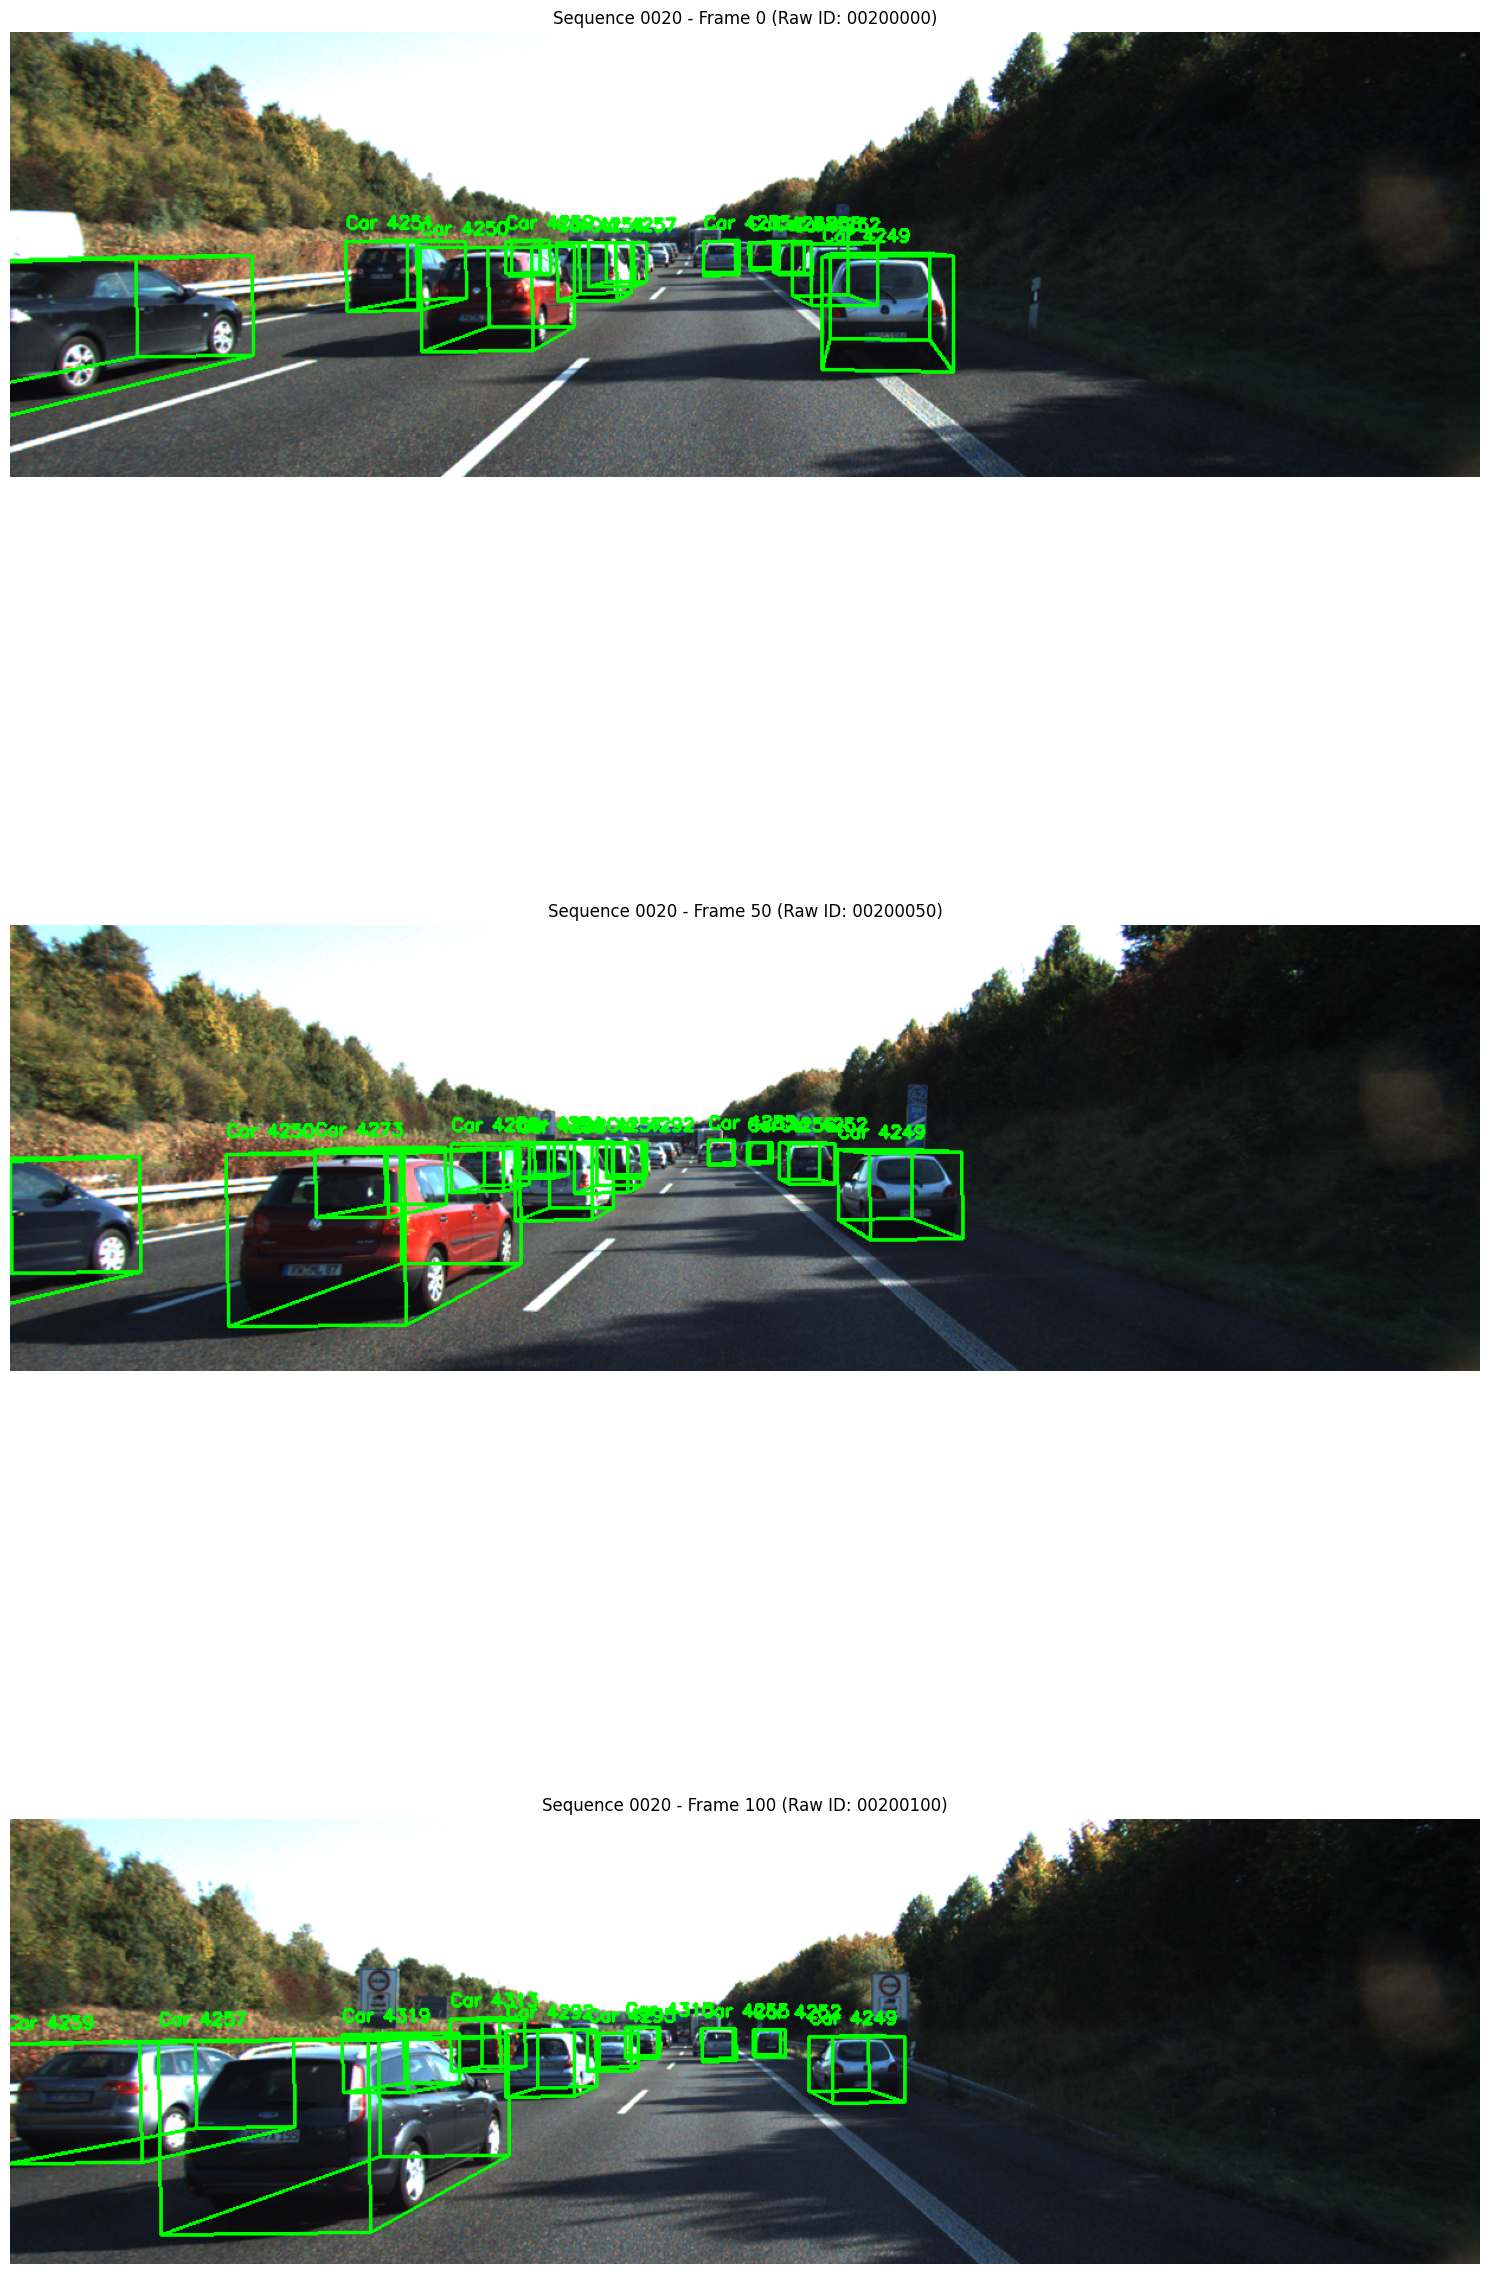

In [ ]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

def load_calib_matrices(filepath):
    """Loads P2 and V2C matrices from a KITTI calibration file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    P2 = calib.get('P2', np.eye(4)[:3, :4]).reshape(3, 4)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    # Matrix to convert Lidar (Velo) to Cam
    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

# Paths to images and calibration
image_dir = '/content/drive/MyDrive/Kitti_tracking/training/image_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

# Select a sequence and some frames
seq_id = '0020'
sample_frames = [0, 50, 100]

calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
if not os.path.exists(calib_file):
    print(f"Warning: Calibration file missing for {seq_id}")
else:
    # Load calibration matrices
    P2, V2C = load_calib_matrices(calib_file)

    # Set up plot
    fig, axes = plt.subplots(len(sample_frames), 1, figsize=(15, 10 * len(sample_frames)))
    if len(sample_frames) == 1:
        axes = [axes]

    for ax, frame_num in zip(axes, sample_frames):
        # 1. Find the correct raw_frame_id from the sequences dictionary
        seq_frames = sequences.get(seq_id, [])
        matching_frame_data = [f for f in seq_frames if f['parsed_frame_num'] == frame_num]

        if not matching_frame_data:
            print(f"Frame {frame_num} not found in sequence {seq_id} data.")
            continue

        # Take the first match
        frame_data = matching_frame_data[0]
        raw_frame_id = str(frame_data['frame_id'])

        # 2. Get tracking results using the exact raw_frame_id
        frame_tracks = tracking_results.get(seq_id, {}).get(raw_frame_id, [])

        # Format frame number as 6 digits for the image path
        frame_str = str(frame_num).zfill(6)
        image_path = os.path.join(image_dir, seq_id, f"{frame_str}.png")

        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue

        # Load image
        img = cv2.imread(image_path)
        if img is None:
             print(f"Could not read image: {image_path}")
             continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw tracks
        for track in frame_tracks:
            state = track['state']
            track_id = track['track_id']
            cls_name = track['class_name']

            corners_2d = project_3d_to_2d(state, V2C, P2)
            img_rgb = draw_3d_box(img_rgb, corners_2d, track_id, cls_name, color=(0, 255, 0))

        ax.imshow(img_rgb)
        ax.set_title(f"Sequence {seq_id} - Frame {frame_num} (Raw ID: {raw_frame_id})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
